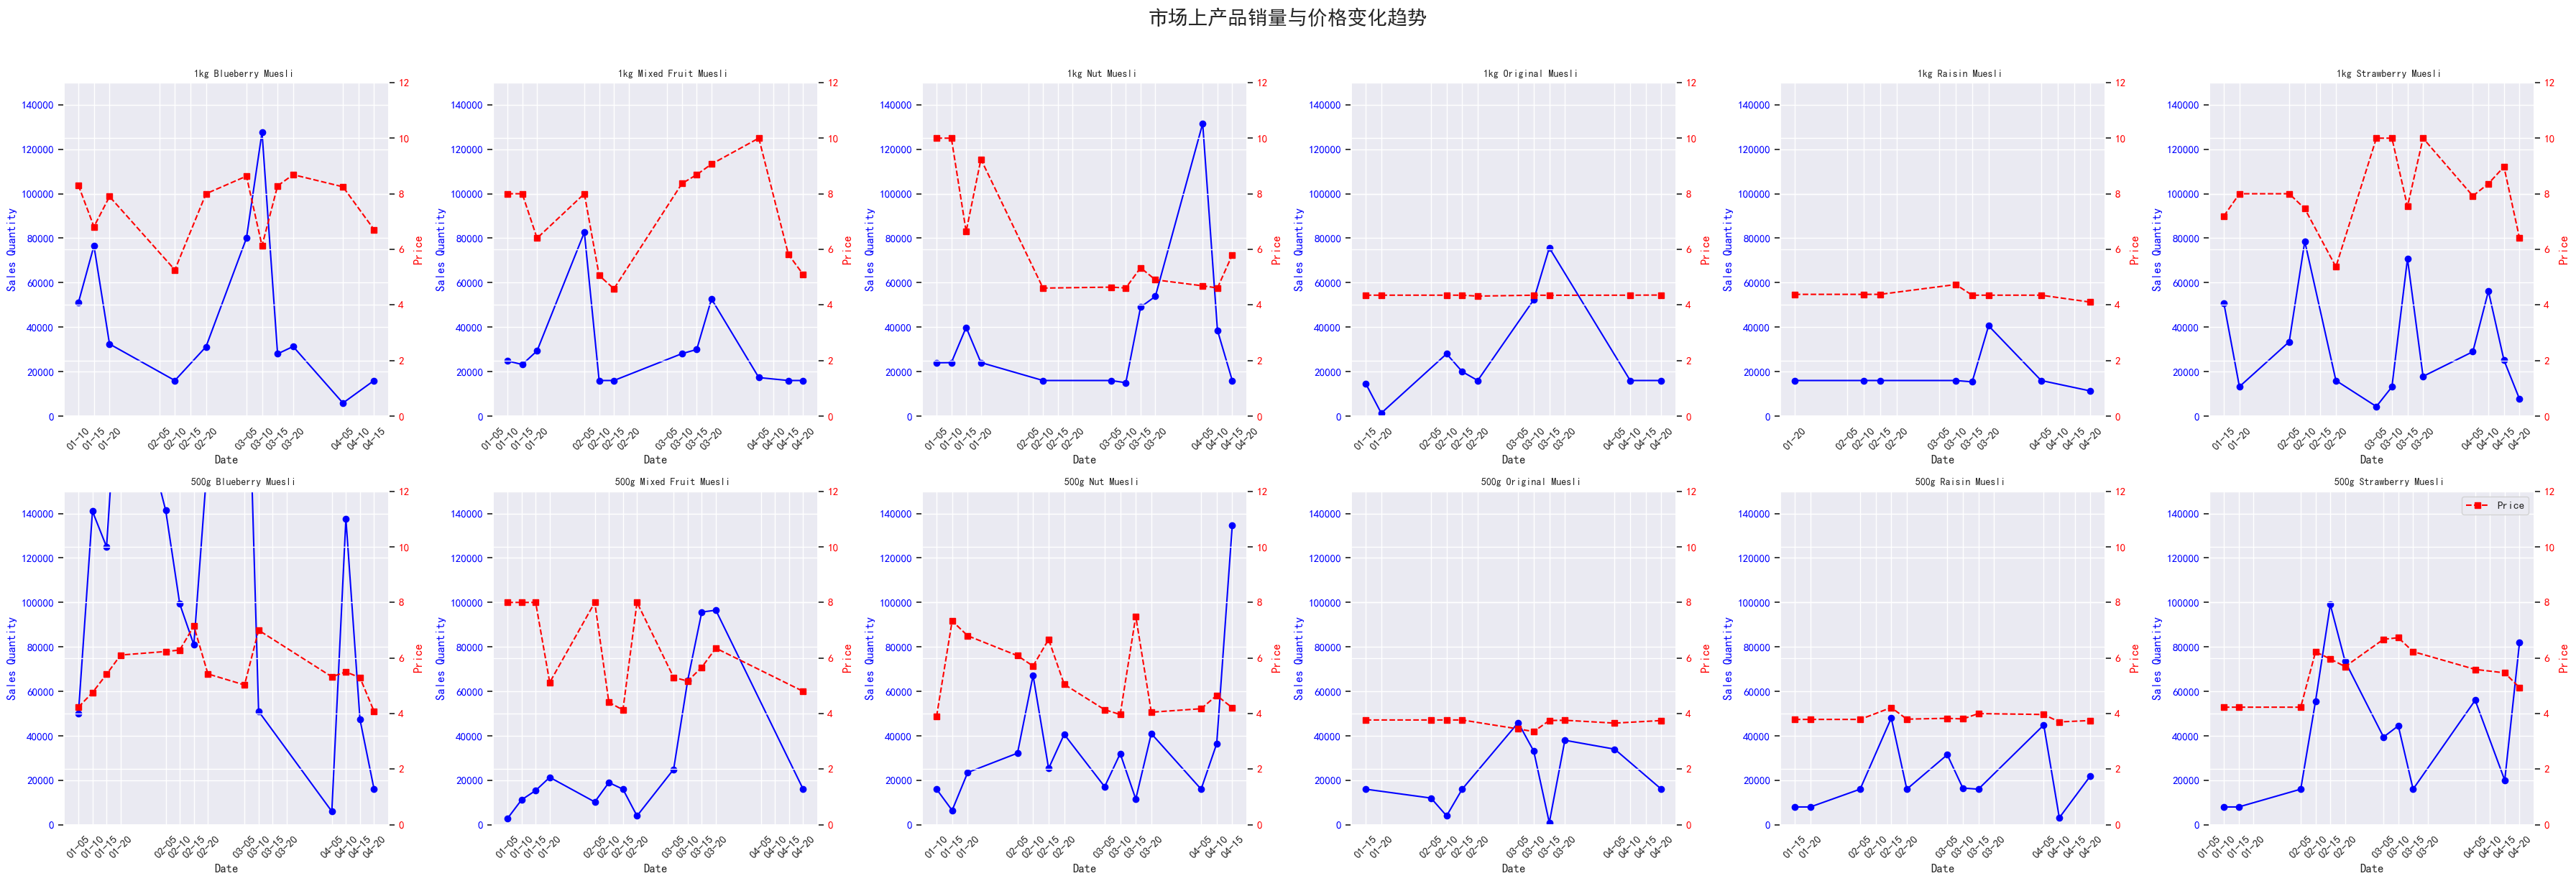

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 读取Excel数据（包含Price列）
df = pd.read_excel('市场销售报告.xlsx', sheet_name='Sheet1')
rows, _ = df.shape

# 提取所需列（新增Price列）
df = df.loc[6:rows, ['Unnamed: 1', 'Unnamed: 2', 'Unnamed: 4', 'Unnamed: 6']]
df.columns = ['Date', 'Material Description', 'Qty', 'Price']

# 数据处理
df['Date'] = df['Date'].str.strip()
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d')
# print(df['Date'].unique())

df['Qty'] = df['Qty'].str.replace(',', '').astype(float)
df['Price'] = df['Price'].astype(float)  # 确保价格为数值

# 按产品和日期聚合（总销量 + 平均价格）
grouped = df.groupby(['Material Description', 'Date']).agg({'Qty': 'sum', 'Price': 'mean'}).reset_index()

# 配置绘图参数
products = grouped['Material Description'].unique()
sns.set_theme()

# 设置中文字体为黑体
plt.rcParams['font.sans-serif'] = ['SimHei']
# 解决负号显示问题
plt.rcParams['axes.unicode_minus'] = False
fig, axes = plt.subplots(2, 6, figsize=(36, 12))
fig.suptitle(f'市场上产品销量与价格变化趋势', fontsize=20, y=1.02)
plt.subplots_adjust(hspace=0.5, wspace=0.3)

# 绘制双轴折线图
for idx, product in enumerate(products):
    ax = axes[idx//6, idx%6]
    data = grouped[grouped['Material Description'] == product]
    
    # 销量轴（左侧）
    ax.plot(data['Date'], data['Qty'], marker='o', linestyle='-', color='blue', label='Sales Qty')
    ax.set_title(product, fontsize=10)
    ax.set_xlabel('Date')
    ax.set_ylabel('Sales Quantity', color='blue')
    ax.tick_params(axis='y', labelcolor='blue')
    ax.set_ylim(0, 150000)
    
    # 价格轴（右侧）
    ax2 = ax.twinx()
    ax2.plot(data['Date'], data['Price'], marker='s', linestyle='--', color='red', label='Price')
    ax2.set_ylabel('Price', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(0, 12)
    
    # 日期格式设置
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(bymonthday=[5, 10, 15, 20]))
    plt.setp(ax.get_xticklabels(), rotation=45)

# 显示图例
plt.legend()

# 保存图片
plt.savefig(f'市场销售报告.png',
            bbox_inches='tight',
            dpi=300)

# 调整布局
plt.tight_layout()
plt.show()